# Analisis de Fraude DBSCAN

Lucho Ene / Jan | 2022 <br>
You Can't Always Get What You Want by Rolling Stones

###  Credit Card Fraud Detection Dataset

Este dataset contiene información sobre transacciones realizadas con tarjetas de crédito por titulares europeos durante septiembre de 2013. Las transacciones corresponden a un período de aproximadamente dos días.

El objetivo del dataset es desarrollar modelos de Machine Learning capaces de detectar transacciones fraudulentas.

Cuenta con **284.807** transacciones, de las cuales **492** son fraudulentas, por lo que presenta un fuerte desbalance entre las clases.

---

####  Variables del dataset

El dataset contiene 31 variables:

| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **Time** | Numérica | Cantidad de segundos transcurridos desde la primera transacción registrada en el dataset. |
| **V1** | Numérica | Primera componente principal (PCA) de las variables originales de la transacción. |
| **V2** | Numérica | Segunda componente principal (PCA). |
| **V3** | Numérica | Tercera componente principal (PCA). |
| **V4** | Numérica | Cuarta componente principal (PCA). |
| **V5** | Numérica | Quinta componente principal (PCA). |
| **V6** | Numérica | Sexta componente principal (PCA). |
| **V7** | Numérica | Séptima componente principal (PCA). |
| **V8** | Numérica | Octava componente principal (PCA). |
| **V9** | Numérica | Novena componente principal (PCA). |
| **V10** | Numérica | Décima componente principal (PCA). |
| **V11** | Numérica | Undécima componente principal (PCA). |
| **V12** | Numérica | Duodécima componente principal (PCA). |
| **V13** | Numérica | Decimotercera componente principal (PCA). |
| **V14** | Numérica | Decimocuarta componente principal (PCA). |
| **V15** | Numérica | Decimoquinta componente principal (PCA). |
| **V16** | Numérica | Decimosexta componente principal (PCA). |
| **V17** | Numérica | Decimoséptima componente principal (PCA). |
| **V18** | Numérica | Decimoctava componente principal (PCA). |
| **V19** | Numérica | Decimonovena componente principal (PCA). |
| **V20** | Numérica | Vigésima componente principal (PCA). |
| **V21** | Numérica | Vigésima primera componente principal (PCA). |
| **V22** | Numérica | Vigésima segunda componente principal (PCA). |
| **V23** | Numérica | Vigésima tercera componente principal (PCA). |
| **V24** | Numérica | Vigésima cuarta componente principal (PCA). |
| **V25** | Numérica | Vigésima quinta componente principal (PCA). |
| **V26** | Numérica | Vigésima sexta componente principal (PCA). |
| **V27** | Numérica | Vigésima séptima componente principal (PCA). |
| **V28** | Numérica | Vigésima octava componente principal (PCA). |
| **Amount** | Numérica | Importe de la transacción. |
| **Class** | Binaria | Variable objetivo que indica si la transacción es fraudulenta o legítima. |

---

####  Variables V1 a V28

Las variables **V1 a V28** no representan directamente características interpretables de la transacción.

Por motivos de confidencialidad, las variables originales fueron transformadas mediante **PCA** (Principal Component Analysis) y posteriormente anonimizadas.

Por lo tanto, no podemos afirmar que, por ejemplo, V14 represente el tipo de comercio o que V7 represente la ubicación. Cada una corresponde a una componente principal derivada de las variables originales.

Estas variables son utilizadas como características de entrada para los modelos de Machine Learning.

---

####  Variable Time

**Time** representa el número de segundos transcurridos desde la primera transacción del dataset.

Por ejemplo, un valor mayor de `Time` indica que la transacción ocurrió más tarde dentro del período de aproximadamente dos días registrado.

Esta variable permite analizar aspectos relacionados con el momento en que se realizó la transacción.

---

#### Variable Amount

**Amount** representa el importe de la transacción realizada con la tarjeta de crédito.

Es una de las variables originales que no fue transformada mediante PCA, por lo que mantiene una interpretación directa.

Puede utilizarse para analizar si existen diferencias en los importes entre las transacciones legítimas y fraudulentas.

---

####  Variable Class

**Class** es la variable objetivo (*target*) del dataset y determina si una transacción es legítima o fraudulenta.

| Valor | Significado |
| :---: | :--- |
| **0** | Transacción legítima |
| **1** | Transacción fraudulenta |

Esta variable es la que el modelo deberá aprender a predecir a partir de las demás características.

---

#### Desbalance de clases

Uno de los principales desafíos del dataset es el enorme desbalance entre las dos categorías de **Class**:

- **284.315** transacciones legítimas.
- **492** transacciones fraudulentas.

Esto significa que aproximadamente el **99,83 %** de las transacciones son legítimas y solamente el **0,17 %** son fraudulentas.

Por este motivo, la *accuracy* por sí sola no es una métrica suficiente para evaluar un modelo, ya que un modelo que predijera todas las transacciones como legítimas podría obtener una *accuracy* muy alta sin detectar ningún fraude.

En este problema resulta especialmente importante analizar métricas como **Precision**, **Recall**, **F1-Score** y **PR-AUC**.

---

#### Resumen de las variables

En términos generales, podemos dividir las variables en cuatro grupos:

- **Time** → Momento relativo de la transacción.
- **V1 - V28** → Características anonimizadas obtenidas mediante PCA.
- **Amount** → Importe de la transacción.
- **Class** → Variable objetivo (`0` = Legítima, `1` = Fraudulenta).

> **Objetivo final:** Utilizar **Time**, **V1–V28** y **Amount** para predecir correctamente el valor de **Class** y, de esta manera, identificar las transacciones potencialmente fraudulentas.

Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud#creditcard.csv

### Import Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


import os, glob, re, json, time, warnings
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons

warnings.filterwarnings('ignore')
# Evitar mensajes de joblib/loky relacionados con los núcleos físicos
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

### Import Datasets

In [2]:
df = pd.read_csv(r"creditcard.csv")
df_raw = df.copy()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.duplicated().sum()

1081

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


#### Desarrollo DBSCAN

Preparacion del conjunto de datos

In [9]:
df = df.drop(["Time", "Amount"], axis=1)

In [10]:
X = df[["V10", "V14"]].copy()
y = df["Class"].copy()

In [11]:
dbscan = DBSCAN(eps=0.15, min_samples=13)
dbscan.fit(X)

DBSCAN(eps=0.15, min_samples=13)

In [12]:
def plot_dbscan(dbscan, X, size):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker=".", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

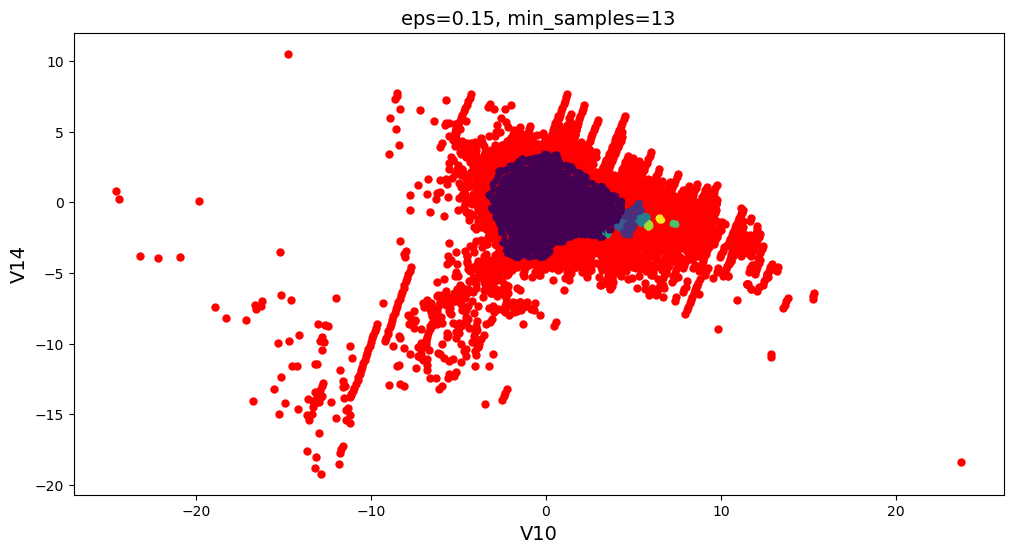

In [13]:
plt.figure(figsize=(12, 6))
plot_dbscan(dbscan, X.values, size=100)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()



In [14]:
counter = Counter(dbscan.labels_.tolist())
bad_counter = Counter(dbscan.labels_[y == 1].tolist())

for key in sorted(counter.keys()):
    print("Label {0} has {1} samples - {2} are malicious samples".format(
        key, counter[key], bad_counter[key]))



Label -1 has 3599 samples - 392 are malicious samples
Label 0 has 279717 samples - 81 are malicious samples
Label 1 has 263 samples - 0 are malicious samples
Label 2 has 41 samples - 0 are malicious samples
Label 3 has 50 samples - 0 are malicious samples
Label 4 has 13 samples - 0 are malicious samples
Label 5 has 13 samples - 0 are malicious samples
Label 6 has 17 samples - 0 are malicious samples
Label 7 has 13 samples - 0 are malicious samples


Reduccion de dimensionalidad

In [15]:
X = df.drop("Class", axis=1)
y = df["Class"].copy()

In [16]:
clf_rnd = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf_rnd.fit(X, y)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [17]:
# Seleccionamos las características más importantes
feature_importances = {name: score for name, score in zip(list(df), clf_rnd.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)

In [18]:
# Reducimos el conjunto de datos a las 7 características más importantes
X_reduced = X[list(feature_importances_sorted.head(7).index)].copy()

In [19]:
X_reduced

,V17,V14,V16,V12,V10,V11,V18
0,0.207971,-0.311169,-0.470401,-0.617801,0.090794,-0.551600,0.025791
1,-0.114805,-0.143772,0.463917,1.065235,-0.166974,1.612727,-0.183361
2,1.109969,-0.165946,-2.890083,0.066084,0.207643,0.624501,-0.121359
3,-0.684093,-0.287924,-1.059647,0.178228,-0.054952,-0.226487,1.965775
4,-0.237033,-1.119670,-0.451449,0.538196,0.753074,-0.822843,-0.038195
...,...,...,...,...,...,...,...
284802,1.991691,4.626942,1.107641,2.711941,4.356170,-1.593105,0.510632
284803,-0.025693,-0.675143,-0.711757,0.915802,-0.975926,-0.150189,-1.221179
284804,0.313502,-0.510602,0.140716,0.063119,-0.484782,0.411614,0.395652
284805,0.509928,0.449624,-0.608577,-0.962886,-0.399126,-1.933849,1.113981


Entrenamiento con Conjunto de datos reducido

In [20]:
dbscan = DBSCAN(eps=0.70, min_samples=25)
dbscan.fit(X_reduced)

DBSCAN(eps=0.7, min_samples=25)

In [21]:
counter = Counter(dbscan.labels_.tolist())
bad_counter = Counter(dbscan.labels_[y == 1].tolist())

for key in sorted(counter.keys()):
    print("Label {0} has {1} samples - {2} are malicious samples".format(
        key, counter[key], bad_counter[key]))



Label -1 has 24404 samples - 426 are malicious samples
Label 0 has 256770 samples - 47 are malicious samples
Label 1 has 979 samples - 0 are malicious samples
Label 2 has 1126 samples - 0 are malicious samples
Label 3 has 75 samples - 0 are malicious samples
Label 4 has 44 samples - 0 are malicious samples
Label 5 has 86 samples - 0 are malicious samples
Label 6 has 26 samples - 0 are malicious samples
Label 7 has 31 samples - 0 are malicious samples
Label 8 has 55 samples - 0 are malicious samples
Label 9 has 67 samples - 0 are malicious samples
Label 10 has 17 samples - 0 are malicious samples
Label 11 has 46 samples - 0 are malicious samples


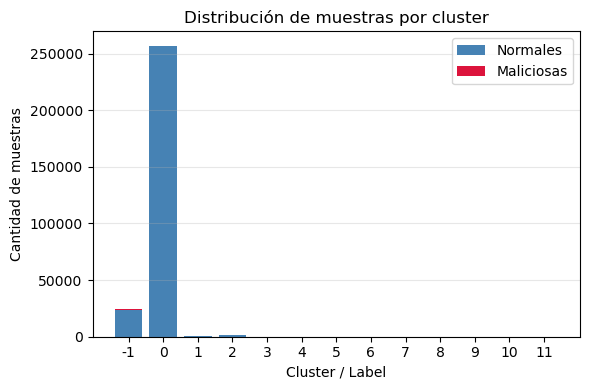

In [22]:
counter = Counter(dbscan.labels_.tolist())
bad_counter = Counter(dbscan.labels_[y == 1].tolist())

labels = sorted(counter.keys())
total = [counter[label] for label in labels]
malicious = [bad_counter[label] for label in labels]
normal = [total[i] - malicious[i] for i in range(len(labels))]

x = np.arange(len(labels))

plt.figure(figsize=(6, 4))

plt.bar(x, normal, label="Normales", color="steelblue")
plt.bar(x, malicious, bottom=normal, label="Maliciosas", color="crimson")

plt.xlabel("Cluster / Label")
plt.ylabel("Cantidad de muestras")
plt.title("Distribución de muestras por cluster")
plt.xticks(x, labels)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
def purity_score(y_true, y_pred):
    # compute contingency matrix (also called confusion matrix)
    contingency_matrix = metrics.cluster.contingency_matrix(y_true, y_pred)
    # return purity
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)


In [24]:
# Obtenemos los clusters del objeto dbscan
clusters = dbscan.labels_

In [25]:
# Calculamos el purity score, es importante darse cuenta de que recibe las etiquetas
print("Purity Score:", purity_score(y, clusters))

Purity Score: 0.9983328986416472


In [26]:
# Calculamos el coeficiente de Shiloutte, es importante darse cuenta de que no le pasamos las etiquetas
print("Shiloutte: ", metrics.silhouette_score(X_reduced, clusters, sample_size=10000))



Shiloutte:  0.1168284734532947


In [27]:
# Calculamos el Calinski harabasz score, es importante darse cuenta de que no le pasamos las etiquetas
print("Calinski harabasz: ", metrics.calinski_harabasz_score(X_reduced, clusters))



Calinski harabasz:  997.381960410626


In [28]:
# Calculamos las métricas
purity = purity_score(y, clusters)

silhouette = metrics.silhouette_score(X_reduced,clusters,sample_size=10000)

calinski = metrics.calinski_harabasz_score(X_reduced,clusters)

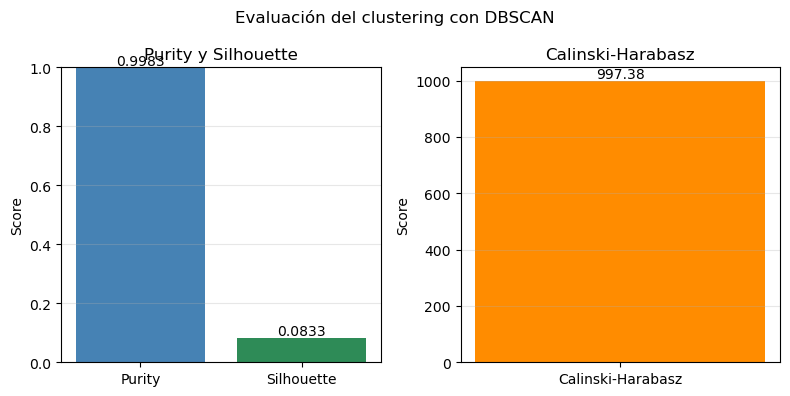

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Purity + Silhouette

metricas_1 = ["Purity", "Silhouette"]
valores_1 = [purity, silhouette]

bars1 = ax[0].bar(
    metricas_1,
    valores_1,
    color=["steelblue", "seagreen"]
)

ax[0].set_ylim(0, 1)
ax[0].set_ylabel("Score")
ax[0].set_title("Purity y Silhouette")
ax[0].grid(axis="y", alpha=0.3)

for bar, valor in zip(bars1, valores_1):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{valor:.4f}",
        ha="center",
        va="bottom"
    )



# Calinski-Harabasz

bars2 = ax[1].bar(
    ["Calinski-Harabasz"],
    [calinski],
    color="darkorange"
)

ax[1].set_ylabel("Score")
ax[1].set_title("Calinski-Harabasz")
ax[1].grid(axis="y", alpha=0.3)

ax[1].text(
    bars2[0].get_x() + bars2[0].get_width() / 2,
    bars2[0].get_height(),
    f"{calinski:.2f}",
    ha="center",
    va="bottom"
)

plt.suptitle("Evaluación del clustering con DBSCAN")
plt.tight_layout()
plt.show()

###### Otro ejemplo de silloutte

In [30]:
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

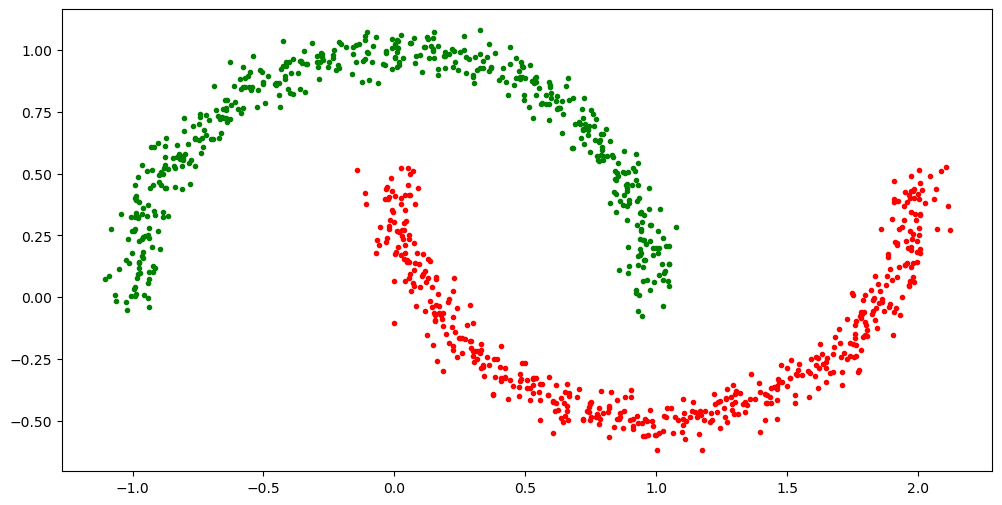

In [31]:
plt.figure(figsize=(12, 6))
plt.scatter(X[:,0][y == 0], X[:,1][y == 0], c="g", marker=".")
plt.scatter(X[:,0][y == 1], X[:,1][y == 1], c="r", marker=".")
plt.show()

In [32]:
dbscan = DBSCAN(eps=0.1, min_samples=6)
dbscan.fit(X)

DBSCAN(eps=0.1, min_samples=6)

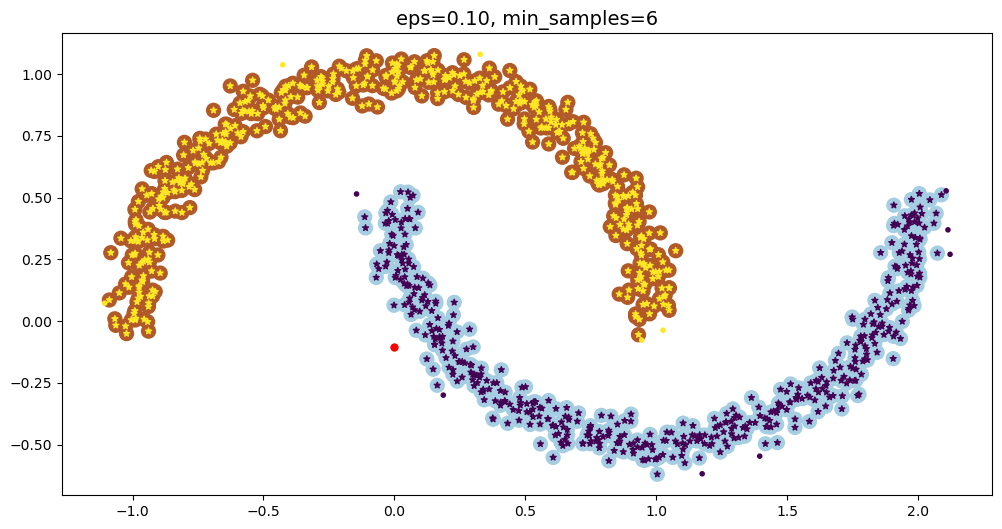

In [33]:
# Representamos el límite de decisión
plt.figure(figsize=(12, 6))
plot_dbscan(dbscan, X, size=100)
plt.show()

In [34]:
counter = Counter(dbscan.labels_.tolist())
bad_counter = Counter(dbscan.labels_[y == 1].tolist())

for key in sorted(counter.keys()):
    print("Label {0} has {1} samples - {2} are malicious samples".format(
        key, counter[key], bad_counter[key]))

Label -1 has 1 samples - 1 are malicious samples
Label 0 has 499 samples - 499 are malicious samples
Label 1 has 500 samples - 0 are malicious samples


### K-means

In [35]:
def plot_data(X, y):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'k.', markersize=2)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'r.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=50, linewidths=50,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, y, resolution=1000, show_centroids=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X, y)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

In [36]:
df = df_raw.copy()

In [37]:
df = df.drop(["Time", "Amount"], axis=1)

In [38]:
X = df[["V10", "V14"]].copy()
X

,V10,V14
0,0.090794,-0.311169
1,-0.166974,-0.143772
2,0.207643,-0.165946
3,-0.054952,-0.287924
4,0.753074,-1.119670
...,...,...
284802,4.356170,4.626942
284803,-0.975926,-0.675143
284804,-0.484782,-0.510602
284805,-0.399126,0.449624


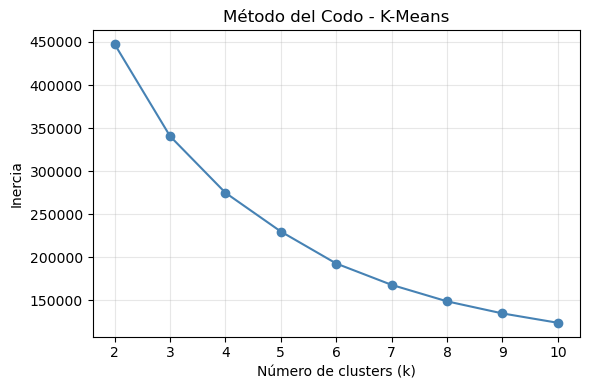

In [39]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans( n_clusters=k,random_state=42,n_init=10)
    
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)


# Visualización del método del codo
plt.figure(figsize=(6, 4))

plt.plot( k_range, inertias, marker="o", color="steelblue")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo - K-Means")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

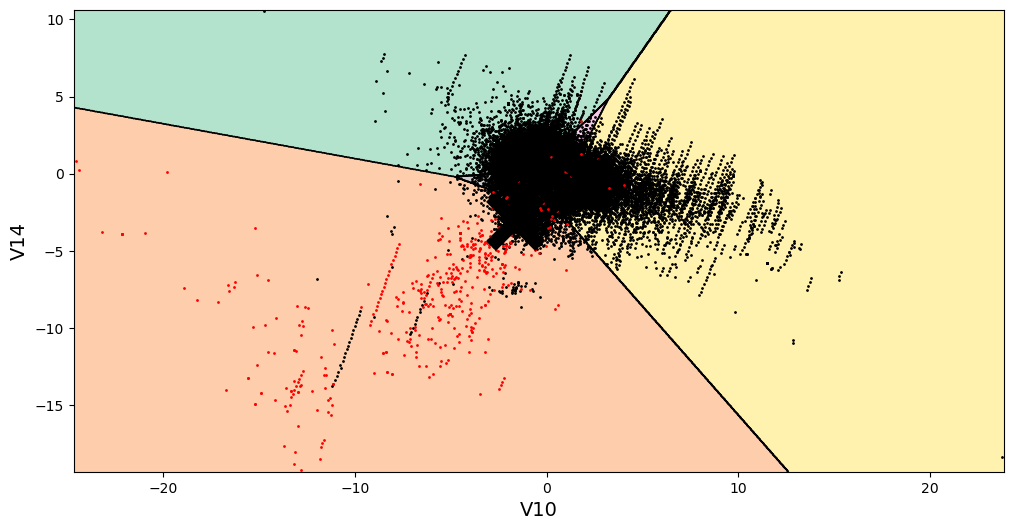

In [41]:
plt.figure(figsize=(12, 6))
plot_decision_boundaries(kmeans, X.values, df["Class"].values)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

In [42]:
counter = Counter(clusters.tolist())
bad_counter = Counter(clusters[df['Class'] == 1].tolist())

for key in sorted(counter.keys()):
    print("Label {0} has {1} samples - {2} are malicious samples".format(
        key, counter[key], bad_counter[key]))



Label 0 has 48659 samples - 6 are malicious samples
Label 1 has 5631 samples - 429 are malicious samples
Label 2 has 121724 samples - 18 are malicious samples
Label 3 has 27404 samples - 8 are malicious samples
Label 4 has 81389 samples - 31 are malicious samples


Conjunto Multidimensional

In [43]:
X = df.drop("Class", axis=1)
y = df["Class"].copy()

In [44]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

In [45]:
# Evaluamos los clusters y el contenido que se han formado
counter = Counter(clusters.tolist())
bad_counter = Counter(clusters[y == 1].tolist())

for key in sorted(counter.keys()):
    print("Label {0} has {1} samples - {2} are malicious samples".format(
        key, counter[key], bad_counter[key]))



Label 0 has 44522 samples - 228 are malicious samples
Label 1 has 100946 samples - 81 are malicious samples
Label 2 has 17163 samples - 0 are malicious samples
Label 3 has 3630 samples - 129 are malicious samples
Label 4 has 118546 samples - 54 are malicious samples


Reduccion de caracteristicas

In [46]:
clf_rnd = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf_rnd.fit(X, y)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [47]:
# Seleccionamos las características más importantes
feature_importances = {name: score for name, score in zip(list(df), clf_rnd.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)

In [48]:
# Reducimos el conjunto de datos a las 7 características más importantes
X_reduced = X[list(feature_importances_sorted.head(7).index)].copy()

In [49]:
X_reduced

,V17,V14,V16,V12,V10,V11,V18
0,0.207971,-0.311169,-0.470401,-0.617801,0.090794,-0.551600,0.025791
1,-0.114805,-0.143772,0.463917,1.065235,-0.166974,1.612727,-0.183361
2,1.109969,-0.165946,-2.890083,0.066084,0.207643,0.624501,-0.121359
3,-0.684093,-0.287924,-1.059647,0.178228,-0.054952,-0.226487,1.965775
4,-0.237033,-1.119670,-0.451449,0.538196,0.753074,-0.822843,-0.038195
...,...,...,...,...,...,...,...
284802,1.991691,4.626942,1.107641,2.711941,4.356170,-1.593105,0.510632
284803,-0.025693,-0.675143,-0.711757,0.915802,-0.975926,-0.150189,-1.221179
284804,0.313502,-0.510602,0.140716,0.063119,-0.484782,0.411614,0.395652
284805,0.509928,0.449624,-0.608577,-0.962886,-0.399126,-1.933849,1.113981


In [50]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_reduced)

In [51]:
# Evaluamos los clusters y el contenido que se han formado
counter = Counter(clusters.tolist())
bad_counter = Counter(clusters[y == 1].tolist())

for key in sorted(counter.keys()):
    print("Label {0} has {1} samples - {2} are malicious samples".format(
        key, counter[key], bad_counter[key]))



Label 0 has 109253 samples - 19 are malicious samples
Label 1 has 124538 samples - 17 are malicious samples
Label 2 has 30408 samples - 161 are malicious samples
Label 3 has 308 samples - 265 are malicious samples
Label 4 has 20300 samples - 30 are malicious samples


Metricas

In [52]:
# Calculamos el purity score, es importante darse cuenta de que recibe las etiquetas
print("Purity Score:", purity_score(y, clusters))

# Calculamos el coeficiente de Shiloutte, es importante darse cuenta de que no le pasamos las etiquetas
print("Shiloutte: ", metrics.silhouette_score(X_reduced, clusters, sample_size=10000))

# Calculamos el Calinski harabasz score, es importante darse cuenta de que no le pasamos las etiquetas
print("Calinski harabasz: ", metrics.calinski_harabasz_score(X_reduced, clusters))

Purity Score: 0.9990519895929524
Shiloutte:  0.17544284626915135
Calinski harabasz:  38466.001407022675


### Conclusion

Se probaron dos algoritmos de clustering no supervisado, **DBSCAN** y **K-Means**, para ver si las transacciones fraudulentas quedan agrupadas o aisladas sin usar la etiqueta `Class` durante el entrenamiento. La etiqueta se usó solo para evaluar.
 
- Se probó con 2 variables (**V10** y **V14**) y con las **7 variables más importantes** según un Random Forest.
- Antes de modelar se eliminaron 1.081 duplicados, quedando 283.726 transacciones, 473 de ellas fraudulentas.
Resultados principales
 
| Modelo | Qué marca como sospechoso | Fraudes capturados | Precisión |
|---|---|---|---|
| DBSCAN, 2 variables | 3.599 (outliers) | 392 de 473 (~83 %) | ~11 % |
| DBSCAN, 7 variables | 24.404 (outliers) | 426 de 473 (~90 %) | ~1,7 % |
| K-Means, 2 variables | cluster 1: 5.631 | 429 de 492 (~87 %) | ~7,6 % |
| K-Means, 7 variables | cluster 3: 308 | 265 de 492 (~54 %) | ~86 % |
 
La precisión de cada fila es la proporción de fraudes dentro de lo que el modelo marca. Para comparar, en el dataset completo esa proporción es de apenas **0,17 %**. Todos los modelos concentran el fraude muchas veces por encima del azar.
 
Lectura de los resultados
 
1. **El fraude sí es "anómalo" en el espacio de las variables.** Casi todos los clusters grandes son legítimos, y los fraudes tienden a caer en la zona de ruido de DBSCAN o en clusters chicos de K-Means. Esto confirma que V10 y V14 (y las otras variables top) separan bastante bien el fraude.
2. **Hay un trade-off entre recall y precisión.**
   - Con más variables, DBSCAN detecta más fraudes (90 %) pero marca muchísimas transacciones legítimas: 24.404 alertas para 426 fraudes no es operable.
   - K-Means con 7 variables hace lo contrario: un cluster muy limpio (86 % de fraude) pero que cubre solo la mitad de los casos.
3. **Siempre quedan fraudes escondidos.** Entre 47 y 81 fraudes caen dentro del cluster "normal" de DBSCAN. Son fraudes que se parecen al comportamiento legítimo y que este enfoque no puede ver.
4. **El ejemplo `make_moons` muestra la ventaja de DBSCAN.** Separa formas no convexas casi perfecto (499/500 y 1 de ruido), cosa que K-Means no puede. En fraude, DBSCAN es más natural como detector de anomalías y K-Means como segmentador.
Cuidado con las métricas
 
- **El Purity Score engaña.** El de DBSCAN (0,9983) coincide exactamente con el baseline de predecir todo como legítimo (283.253 / 283.726 = 0,9983). No aporta información en un dataset tan desbalanceado. El de K-Means (0,9990) también está casi pegado al baseline.
- **Silhouette y Calinski-Harabasz indican estructura débil.** Silhouette de 0,12 (DBSCAN) y 0,18 (K-Means) significan clusters poco definidos. Calinski-Harabasz es 997 en DBSCAN y 38.466 en K-Means, pero no son comparables entre algoritmos, porque ese índice favorece clusters compactos y esféricos.
- **Hay un pequeño filtrado de información.** Las 7 variables se eligieron con un Random Forest entrenado con `Class`, así que el enfoque no es 100 % no supervisado. Los hiperparámetros (`eps`, `min_samples`, `k`) también parecen haberse ajustado mirando dónde caían los fraudes.
- **DBSCAN y K-Means no son estrictamente comparables.** DBSCAN se corrió sin duplicados y K-Means con el dataset original (492 fraudes).
- **Todo es in-sample.** No hay separación train/test.
Cierre
 
El clustering no supervisado sirve como **filtro exploratorio o de priorización**, no como detector final. Detecta bien dónde vive el fraude (recall alto), pero con demasiados falsos positivos.
